# SAME PDE WITH MONTE CARLO

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
#array for number of samples
N = np.array([100,500,1000,5000,10000,50000,100000,500000,1000000])

In [3]:
S0, sig0, beta, kappa, eta, lam = 100.0, 0.20, 0.45, 1.5, 0.35, 2.0
r, q, K, T = 0.03, 0.01, 120.0, 1.0

def sigma_lv(S, t):
    z = np.log(S/S0)
    return sig0*(1.0 - beta*np.tanh(kappa*z))*(1.0 + eta*np.exp(-lam*t))

"""N paths, M timesteps."""
def MC(N, M, seed=0):
    rng = np.random.default_rng(seed)
    dt = T/M
    logS = np.full(N, np.log(S0))
    t = 0.0
    for _ in range(M):
        Z = rng.standard_normal(N//2)
        Z = np.concatenate([Z, -Z])              # antithetic
        s = sigma_lv(np.exp(logS), t)
        logS += (r - q - 0.5*s*s)*dt + s*np.sqrt(dt)*Z
        t += dt
    payoff = np.maximum(np.exp(logS) - K, 0.0)
    return np.exp(-r*T)*payoff.mean(), np.exp(-r*T)*payoff.std(ddof=1)/np.sqrt(N)

In [8]:
european_call_payoffs = np.zeros((len(N),2))

for i in range(0, len(N)):
    european_call_payoffs[i,:] = MC(N[i], 500)

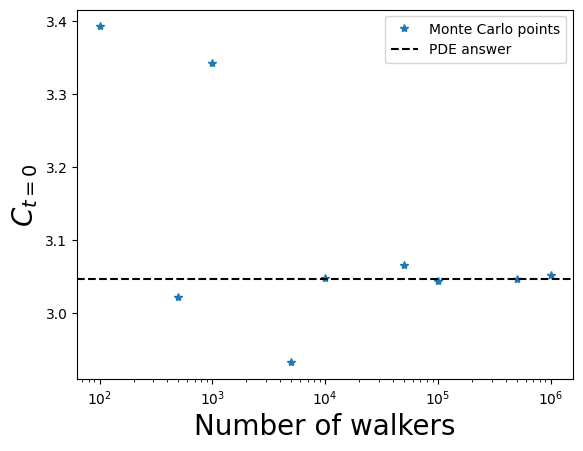

In [30]:
plt.semilogx(N, european_call_payoffs[:,0], '*', label ='Monte Carlo points')
plt.axhline(y = 3.047512056968579, c='black', linestyle='dashed', label ='PDE answer')
plt.xlabel('Number of walkers', fontsize=20)
plt.ylabel(r'$C_{t=0}$', fontsize=20)
plt.legend(fontsize=10)
plt.show()

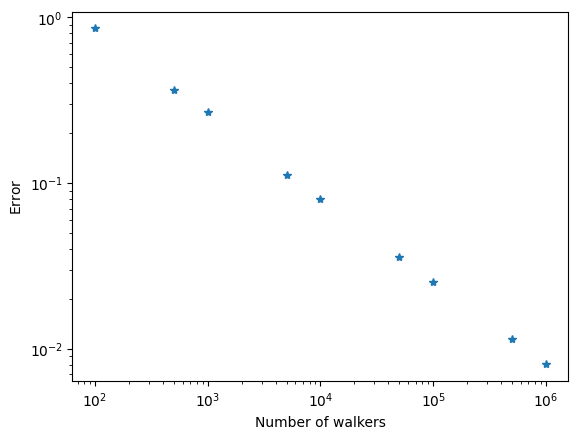

In [26]:
plt.loglog(N, european_call_payoffs[:,1], '*')
plt.xlabel('Number of walkers')
plt.ylabel(r'$\text{Error}$')
plt.show()